In [11]:
# ============================================================
# pareto_matching_combined.py
# ============================================================
# Combines two stages into a single dual-mode (script / Jupyter)
# pipeline:
#
#   STAGE A
#       Reads the raw fluorescence-microscopy tumour data
#       (tumor_metadata.tsv + per-folder parquet/zone files) and
#       computes the Necrotic Core Fraction (NCF) and the full set
#       of simulation-compatible observables for every tumour.
#       Only the bridge file `ncf_per_tumor.csv` is written — the
#       NCF-stage summary CSV and figures are intentionally NOT
#       produced, since the only outputs of interest are the
#       Pareto-matching results (Stage B).
#
#   STAGE B
#       Loads the experimental observables produced in Stage A
#       together with `pareto_summary.csv` (Cancer Metastasis
#       Simulation Pareto front) and finds, for every experimental
#       tumour, which (α, β, γ, N_A) combination(s) best reproduce
#       its phenotype. Produces matching_results.csv,
#       group_summary.csv, a console report, and 6 figures.
#
# Script mode  :  python pareto_matching_combined.py
# Jupyter mode :  run cells top-to-bottom once for setup, then run
#                 each figure cell independently.
#
# To display plots inline in Jupyter, change:
#     SHOW_FIGS = True
# in this cell before running (auto-detected by default).
# ============================================================

from __future__ import annotations
import pathlib
import sys
import warnings
from pathlib import Path

# ── Jupyter auto-detection ────────────────────────────────
try:
    _shell = get_ipython().__class__.__name__          # noqa: F821
    IN_JUPYTER = _shell in ("ZMQInteractiveShell",      # Jupyter notebook / Lab
                             "TerminalInteractiveShell") # ipython terminal
except NameError:
    IN_JUPYTER = False

# ── Backend: set before importing pyplot ─────────────────
import matplotlib
if not IN_JUPYTER:
    matplotlib.use("Agg")   # non-interactive backend for script mode

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines   as mlines
import numpy  as np
import pandas as pd
from sklearn.cluster        import KMeans
from sklearn.preprocessing  import MinMaxScaler

warnings.filterwarnings("ignore")

# ── Output flags  (the only lines you need to change) ────
SAVE_FIGS    = True          # write PNG files to OUT_DIR  (Pareto-stage figures)
SHOW_FIGS    = False    # display inline (auto-True in Jupyter)
SAVE_NCF_CSV = True          # write the ncf_per_tumor.csv bridge file to OUT_DIR

# ── Paths ─────────────────────────────────────────────────
# Stage A (experimental tissue data) ------------------------
BASE_DIR      = "D:/MMRES - Courses/2025-2026/Research Project/TFM/CRG-Minor/bsalgado/image-analysis/results/SLURM-2"   # tumor_metadata.tsv + tumour folders
METADATA_FILE = "tumor_metadata.tsv"

# Stage B (simulation Pareto front) --------------------------
PARETO_CSV    = "D:/MMRES - Courses/2025-2026/Research Project/TFM/Code development/results/final-data/pareto_summary.csv"

# Shared output directory ------------------------------------
OUT_DIR       = "D:/MMRES - Courses/2025-2026/Research Project/TFM/Code development/results/final-data/pareto_matching-2"

# ── Physics constants ─────────────────────────────────────
LAMBDA_NECRO = 1.0   # dissipation weight for necrosis   (Stage A, experimental D)
LAMBDA_META  = 5.0   # dissipation weight for metastasis (Stage A experimental D,
                      # and Stage B's R_sim back-calculation — same simulation default)
N_STRATEGIES = 4      # k-means clusters (mirrors Pareto_results.py)

# Zone labels as they appear in zone_classifications.tsv
ZONE_LIVE       = "live"
ZONE_TRANSITION = "transition"
ZONE_NECROTIC   = "necrotic"
ZONES           = [ZONE_LIVE, ZONE_TRANSITION, ZONE_NECROTIC]

# Channels present in the parquet (ch647 excluded from primary analysis)
INTENSITY_CHANNELS = ["dapi", "ch488", "ch546"]

# ── Matching weights ──────────────────────────────────────
# Relative importance of each observable in the L2 distance.
# Increase a weight to make that observable dominate the ranking.
WEIGHTS = dict(
    ncf    = 1.00,   # primary: NCF (necrotic core fraction)
    C      = 0.50,   # estimated mean hypoxia ratio <C>
    R      = 0.20,   # tumour size  (R_eff ↔ R_sim)
    alpha  = 0.25,   # α via alpha_structural_proxy
    beta   = 0.60,   # β via beta_proxy  ← main discriminator
    gamma  = 0.50,   # γ via condensing_proxy
    bgamma = 0.40,   # β(1+γ) via ki67_gradient
    na     = 0.20,   # N_A via warburg_adaptation
)

# ── Visual style ──────────────────────────────────────────
MEI_THRESHOLD = 0.15
STRAT_COLOR   = {"Necrotic":"#7c3aed","Invasive":"#dc2626",
                 "Efficient":"#059669","Explosive":"#d97706"}
STRAT_MARKER  = {"Necrotic":"s","Invasive":"^","Efficient":"o","Explosive":"D"}
GROUP_COLOR   = {"Control":"#2563eb","Treated":"#db2777"}
GROUP_MARKER  = {"Control":"o","Treated":"^"}

plt.rcParams.update({
    "font.family":"DejaVu Sans",
    "axes.spines.top":False,"axes.spines.right":False,
    "axes.titlesize":11,"axes.labelsize":10,
    "xtick.labelsize":9,"ytick.labelsize":9,
    "legend.fontsize":9,"figure.dpi":140,
})

In [12]:
# %% [Cell 2]  STAGE A — metadata & per-folder data loading
# ============================================================

def load_metadata(base_dir: Path, filename: str = "tumor_metadata.tsv") -> pd.DataFrame:
    """
    Load tumor_metadata.tsv with whitespace-tolerant token parsing.

    The file uses inconsistent whitespace padding rather than strict
    tab-delimiting.  FOLDER is the only field that can contain internal
    spaces (e.g. '2026.05.26 1418_9A2C_A98C_AD6C_20x'), so each data
    line is split on whitespace and the last N-1 tokens are assigned to
    the fixed-width trailing columns (COLUMN, NAME, TREATMENT[, SKIP]);
    the remaining leading tokens are joined to form FOLDER.

    SKIP is optional: its presence is detected from the header row.
    The TREATEMENT typo in the header is silently corrected by assigning
    canonical column names directly from token positions rather than
    reading them from the header.
    """
    meta_path = base_dir / filename
    if not meta_path.exists():
        raise FileNotFoundError(f"Metadata not found: {meta_path}")

    with open(meta_path) as f:
        lines = [line for line in f if line.strip()]

    if not lines:
        return pd.DataFrame(
            columns=["FOLDER", "COLUMN", "NAME", "TREATMENT", "SKIP"]
        )

    # Detect optional SKIP column from the header (TREATEMENT typo is ignored
    # here — we assign canonical names directly in the DataFrame constructor)
    header_tokens = lines[0].split()
    has_skip   = "SKIP" in header_tokens
    n_fixed    = 4 if has_skip else 3   # number of trailing fixed-width fields
    fixed_cols = (["COLUMN", "NAME", "TREATMENT", "SKIP"]
                  if has_skip else
                  ["COLUMN", "NAME", "TREATMENT"])

    rows = []
    for line in lines[1:]:
        tokens = line.split()
        if len(tokens) < n_fixed + 1:   # need at least 1 token for FOLDER
            continue
        folder = " ".join(tokens[:-n_fixed])
        rows.append((folder, *tokens[-n_fixed:]))

    meta = pd.DataFrame(rows, columns=["FOLDER", *fixed_cols])

    # If SKIP was absent, add it as all-False so downstream logic is uniform
    if not has_skip:
        print("[metadata] No SKIP column found — all tumours will be included.")
        meta["SKIP"] = "False"

    # Normalise SKIP to bool
    meta["SKIP"] = meta["SKIP"].str.strip().str.lower() == "true"

    # Parse 'C1' → 1,  'C2' → 2, …
    meta["well_col"] = meta["COLUMN"].str.strip().str.lstrip("Cc").astype(int)

    # Report and drop skipped tumours
    skipped = meta[meta["SKIP"]][["FOLDER", "NAME"]]
    if not skipped.empty:
        print(f"[metadata] Skipping {len(skipped)} tumour(s) (SKIP=True):")
        for _, r in skipped.iterrows():
            print(f"           • {r['NAME'].strip()}  ({r['FOLDER'].strip()})")

    meta = meta[~meta["SKIP"]].copy().reset_index(drop=True)

    meta["FOLDER"]    = meta["FOLDER"].str.strip()
    meta["NAME"]      = meta["NAME"].str.strip()
    meta["TREATMENT"] = meta["TREATMENT"].str.strip()

    return meta


def load_folder_data(
    base_dir: Path, folder: str
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Load the combined_nuclei parquet and zone_classifications.tsv for a folder.

    Returns
    -------
    nuclei_df : pd.DataFrame  — full nucleus-level morphology + intensities
    zone_df   : pd.DataFrame  — nucleus IDs + zone labels + spatial coords
    """
    folder_path  = base_dir / folder
    parquet_path = folder_path / f"{folder}_combined_nuclei.parquet"
    zone_path    = folder_path / "segmentation" / "zone_classifications.tsv"

    if not parquet_path.exists():
        raise FileNotFoundError(f"Parquet not found: {parquet_path}")
    if not zone_path.exists():
        raise FileNotFoundError(f"Zone file not found: {zone_path}")

    nuclei_df = pd.read_parquet(parquet_path)
    zone_df   = pd.read_csv(zone_path, sep="\t")

    # Ensure C is integer in both dataframes
    for df in (nuclei_df, zone_df):
        if "C" in df.columns:
            df["C"] = df["C"].astype(int)

    return nuclei_df, zone_df

In [13]:
# %% [Cell 3]  STAGE A — per-tumour metric functions
# ============================================================

def compute_zone_fractions(zone_df: pd.DataFrame, well_col: int) -> dict:
    """
    Filter zone_df to a single well column and compute zone counts / fractions.

    Viable biomass definition: both live and transition nuclei are intact
    and metabolically active — only necrotic nuclei have truly died.
        viable_fraction = (N_live + N_transition) / N_total = 1 - NCF
        hypoxia_proxy   = F_trans / (1 - NCF)
        alpha_structural_proxy = NCF / F_trans   (death sensitivity proxy)
    """
    sub = zone_df[zone_df["C"] == well_col].copy()
    n_total = len(sub)

    if n_total == 0:
        warnings.warn(f"No nuclei found for well column C={well_col}")
        return {k: np.nan for k in [
            "n_total", "n_necrotic", "n_transition", "n_live",
            "NCF", "transition_fraction", "live_fraction",
            "viable_fraction", "hypoxia_proxy", "alpha_structural_proxy",
        ]}

    n_necrotic   = int((sub["zone"] == ZONE_NECROTIC).sum())
    n_transition = int((sub["zone"] == ZONE_TRANSITION).sum())
    n_live       = int((sub["zone"] == ZONE_LIVE).sum())

    ncf             = n_necrotic   / n_total
    transition_frac = n_transition / n_total
    viable_frac     = (n_live + n_transition) / n_total   # = 1 - NCF

    hypoxia_proxy = (
        transition_frac / viable_frac if viable_frac > 0 else np.nan
    )
    alpha_structural_proxy = (
        ncf / transition_frac if transition_frac > 0 else np.nan
    )

    return {
        "n_total":                n_total,
        "n_necrotic":             n_necrotic,
        "n_transition":           n_transition,
        "n_live":                 n_live,
        "NCF":                    ncf,
        "transition_fraction":    transition_frac,
        "live_fraction":          n_live / n_total,
        "viable_fraction":        viable_frac,
        "hypoxia_proxy":          hypoxia_proxy,
        "alpha_structural_proxy": alpha_structural_proxy,
    }


def compute_effective_radius(zone_df: pd.DataFrame, well_col: int) -> float:
    """
    Estimate the effective tumour radius R_eff from the spatial spread of
    nuclei (gyration radius), comparable across tumours in physical units
    (slide pixels). Enters the Dissipation functional via D = log(R²+1)×….
    """
    sub = zone_df[zone_df["C"] == well_col]
    if sub.empty:
        return np.nan

    x = sub["global_x"].values.astype(float)
    y = sub["global_y"].values.astype(float)

    cx, cy = x.mean(), y.mean()
    r_eff  = float(np.sqrt(np.mean((x - cx) ** 2 + (y - cy) ** 2)))
    return r_eff


def compute_dissipation(
    r_eff: float,
    ncf:   float,
    mei:   float = 0.0,
    lambda_necro: float = LAMBDA_NECRO,
    lambda_meta:  float = LAMBDA_META,
) -> float:
    """
    Dissipation functional (simulation README §4):
        D = log(R² + 1) · (1 + λ_necro · NCF) · (1 + λ_meta · MEI)
    MEI defaults to 0 — metastatic events are not tracked in tissue data.
    """
    if np.isnan(r_eff) or np.isnan(ncf):
        return np.nan
    return (
        np.log(r_eff ** 2 + 1)
        * (1.0 + lambda_necro * ncf)
        * (1.0 + lambda_meta  * mei)
    )


def compute_channel_intensity_by_zone(
    nuclei_df: pd.DataFrame,
    zone_df:   pd.DataFrame,
    well_col:  int,
) -> dict:
    """
    Mean channel intensities (_mean_nuclear_raw) broken down by zone, plus
    derived ratio proxies for the simulation's β, γ and N_A parameters.

      ch488 (KI67)      → β (proliferation rate)
        ki67_gradient = ch488_live / ch488_transition  → β decay into hypoxia
        beta_proxy    = ch488_live / ch488_necrotic    → β contrast, rim vs core

      ch546 (H3K18lac, Warburg marker — NOT hypoxia)   → V_max / N_A
        warburg_contrast   = ch546_live / ch546_necrotic   → V_max/K_M
        warburg_adaptation = ch546_transition / ch546_live → N_A proxy

      condensing_proxy = (KI67_live/DAPI_live) × (H3K18lac_live/DAPI_live)
        → candidate marker for the γ > 0 condensing phenotype.

      alpha is NOT accessible from channel intensities; it is derived
      structurally as alpha_structural_proxy = NCF / transition_fraction
      (see compute_zone_fractions).

    Merge key: (image_id, nucleus_id) — cell_id alone restarts per image
    tile and would create a cartesian-product blow-up across fields.
    """
    sub_zone = zone_df[zone_df["C"] == well_col][["image_id", "nucleus_id", "zone"]]
    sub_nuc  = nuclei_df[nuclei_df["C"] == well_col]

    merged = sub_nuc.merge(sub_zone, on=["image_id", "nucleus_id"], how="inner")

    result = {}
    for ch in INTENSITY_CHANNELS:
        col = f"{ch}_mean_nuclear_raw"
        if col not in merged.columns:
            continue
        for zone in ZONES:
            vals = merged.loc[merged["zone"] == zone, col]
            key  = f"{ch}_{zone}"
            result[key] = float(vals.mean()) if len(vals) > 0 else np.nan

    # KI67 (ch488) derived ratios
    if "ch488_live" in result and "ch488_transition" in result:
        result["ki67_gradient"] = (
            result["ch488_live"] / result["ch488_transition"]
            if result["ch488_transition"] > 0 else np.nan
        )
    if "ch488_live" in result and "ch488_necrotic" in result:
        result["beta_proxy"] = (
            result["ch488_live"] / result["ch488_necrotic"]
            if result["ch488_necrotic"] > 0 else np.nan
        )

    # H3K18lac (ch546) derived ratios
    if "ch546_live" in result and "ch546_necrotic" in result:
        result["warburg_contrast"] = (
            result["ch546_live"] / result["ch546_necrotic"]
            if result["ch546_necrotic"] > 0 else np.nan
        )
    if "ch546_transition" in result and "ch546_live" in result:
        result["warburg_adaptation"] = (
            result["ch546_transition"] / result["ch546_live"]
            if result["ch546_live"] > 0 else np.nan
        )

    # Condensing phenotype proxy (gamma > 0), DAPI-normalised
    if (
        "ch488_live" in result
        and "ch546_live" in result
        and "dapi_live"  in result
        and result.get("dapi_live", 0.0) > 0
    ):
        ki67_norm = result["ch488_live"] / result["dapi_live"]
        lac_norm  = result["ch546_live"] / result["dapi_live"]
        result["condensing_proxy"] = ki67_norm * lac_norm

    return result

In [14]:
# %% [Cell 4]  STAGE A — main computation loop
# ============================================================

def compute_all_metrics(base_dir: Path, meta: pd.DataFrame) -> pd.DataFrame:
    """
    Iterate over all non-skipped tumours and compute the full metric set.
    Returns a DataFrame with one row per tumour — this is the experimental
    observable table consumed directly by Stage B (equivalent to what
    Compute_ncf_crg.py would write to ncf_per_tumor.csv).
    """
    rows = []

    for folder, group in meta.groupby("FOLDER"):
        print(f"\n[folder] {folder}")
        try:
            nuclei_df, zone_df = load_folder_data(base_dir, folder)
        except FileNotFoundError as e:
            print(f"  WARNING: {e} — skipping folder")
            continue

        for _, row in group.iterrows():
            well_col  = int(row["well_col"])
            name      = row["NAME"]
            treatment = row["TREATMENT"]

            zone_metrics = compute_zone_fractions(zone_df, well_col)
            r_eff        = compute_effective_radius(zone_df, well_col)
            dissipation  = compute_dissipation(
                r_eff, zone_metrics.get("NCF", np.nan)
            )
            ch_metrics   = compute_channel_intensity_by_zone(
                nuclei_df, zone_df, well_col
            )

            ncf_val    = zone_metrics.get("NCF", float("nan"))
            viable_val = zone_metrics.get("viable_fraction", float("nan"))
            print(
                f"  * {name:<8s}  col=C{well_col}  "
                f"treatment={treatment:<8s}  "
                f"N={zone_metrics.get('n_total', 0):>6d}  "
                f"NCF={ncf_val:.4f}  viable={viable_val:.4f}"
            )

            rows.append({
                "folder":        folder,
                "well_col":      well_col,
                "name":          name,
                "treatment":     treatment,
                **zone_metrics,
                "R_eff":         r_eff,
                "Dissipation":   dissipation,
                **ch_metrics,
            })

    return pd.DataFrame(rows)

In [15]:
# %% [Cell 5]  STAGE A — run NCF pipeline (no plots / no summary CSV)
# ============================================================
print("=" * 68)
print("  STAGE A — Computing experimental observables (NCF pipeline)")
print("=" * 68)

_base_dir = Path(BASE_DIR).expanduser().resolve()
print(f"Base directory: {_base_dir}")

meta = load_metadata(_base_dir, METADATA_FILE)
print(f"\n[metadata] {len(meta)} tumours loaded after SKIP filter")

exp = compute_all_metrics(_base_dir, meta)
if exp.empty:
    print("\nERROR: No experimental data could be computed. Check file paths above.")
    sys.exit(1)

if SAVE_NCF_CSV:
    _ncf_path = OUT_DIR + "/" + "ncf_per_tumor.csv"
    exp.to_csv(_ncf_path, index=False, float_format="%.6f")
    print(f"\n[output] Per-tumour experimental observables → {_ncf_path}")

print(f"\nStage A complete: {len(exp)} tumours ready for Pareto matching.\n")

  STAGE A — Computing experimental observables (NCF pipeline)
Base directory: D:\MMRES - Courses\2025-2026\Research Project\TFM\CRG-Minor\bsalgado\image-analysis\results\SLURM-2
[metadata] Skipping 1 tumour(s) (SKIP=True):
           • AA11  (2026.05.27 AA11_A9BA_A8A0_20x)

[metadata] 13 tumours loaded after SKIP filter

[folder] 2026.05.26 1418_9A2C_A98C_AD6C_20x
  * 1418      col=C1  treatment=Treated   N=1148662  NCF=0.0776  viable=0.9224
  * 9A2C      col=C2  treatment=Treated   N=812388  NCF=0.0721  viable=0.9279
  * A98C      col=C3  treatment=Control   N=1511351  NCF=0.0380  viable=0.9620
  * AD6C      col=C4  treatment=Treated   N=319419  NCF=0.1689  viable=0.8311

[folder] 2026.05.26 A3FF_9286_B778_BE6F_20x
  * A3FF      col=C1  treatment=Control   N=786739  NCF=0.0156  viable=0.9844
  * 9286      col=C2  treatment=Treated   N=800664  NCF=0.0369  viable=0.9631
  * B778      col=C3  treatment=Control   N=780127  NCF=0.0495  viable=0.9505
  * BE6F      col=C4  treatment=Control 

In [16]:
# %% [Cell 6]  save_figure — central output handler (Stage B figures)
# ============================================================
def save_figure(fig: plt.Figure, filename: str) -> plt.Figure:
    """
    Central figure output handler.

    ┌────────────┬───────────┬──────────────────────────────────────────┐
    │ SAVE_FIGS  │ SHOW_FIGS │ action                                   │
    ├────────────┼───────────┼──────────────────────────────────────────┤
    │    True    │   False   │ write PNG, close figure  (script mode)   │
    │    True    │   True    │ write PNG, display inline (Jupyter+save) │
    │   False    │   True    │ display inline only      (exploration)   │
    │   False    │   False   │ no-op / dry-run                          │
    └────────────┴───────────┴──────────────────────────────────────────┘
    """
    if SAVE_FIGS:
        path = OUT_DIR + "/" + filename
        fig.savefig(path, dpi=150, bbox_inches="tight")
        print(f"  ✓  saved  →  {path}")
    if SHOW_FIGS:
        plt.show()
    else:
        plt.close(fig)
    return fig

In [17]:
# %% [Cell 7]  STAGE B — data-processing functions
# ============================================================

def load_pareto(pareto_path: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load the simulation Pareto-summary CSV; return (full, pareto_front_only)."""
    pareto = pd.read_csv(pareto_path)
    pf     = pareto[pareto["pareto_front"] == True].copy().reset_index(drop=True)
    return pareto, pf


def enrich_pareto_front(pf: pd.DataFrame) -> pd.DataFrame:
    """
    Add three derived columns needed for matching:

    R_sim    effective tumour radius from the Dissipation functional:
             D = R² × (1 + NCF) × (1 + λ·MEI)  →  R = sqrt(D / denom)

    C_est    estimated mean hypoxia ratio for living cells, calibrated so
             NCF_sim = 0.15 (Pareto max) → <C> ≈ 0.525, matching the
             experimental hypoxia_proxy ≈ 0.530:
             C_est = 0.30 + 1.50 × NCF_sim

    b_gamma  effective division rate in the normoxic rim:
             b_live = β × (1 + γ)  — simulation analogue of ki67_gradient
    """
    pf = pf.copy()
    pf["R_sim"]   = np.sqrt(
        pf["mean_dissipation"]
        / ((1 + pf["mean_ncf"]) * (1 + LAMBDA_META * pf["mean_mei"]))
    )
    pf["C_est"]   = 0.30 + 1.50 * pf["mean_ncf"]
    pf["b_gamma"] = pf["beta"] * (1 + pf["gamma"])
    return pf


def classify_strategies(pf: pd.DataFrame) -> pd.DataFrame:
    """
    K-means (k=4) in normalised 4D objective space, identical to
    Pareto_results.py.  Cluster labels are assigned by their
    dominant characteristic:
        Efficient  → highest mean Fitness
        Invasive   → highest mean MEI
        Necrotic   → highest mean NCF
        Explosive  → remaining cluster (highest mean Dissipation)
    """
    obj_cols = ["mean_fitness","mean_mei","mean_ncf","mean_dissipation"]
    scaler   = MinMaxScaler()
    X        = scaler.fit_transform(pf[obj_cols])
    km       = KMeans(n_clusters=N_STRATEGIES, random_state=42, n_init=10).fit(X)
    pf       = pf.copy()
    pf["strat_id"] = km.labels_
    centers  = pd.DataFrame(
        scaler.inverse_transform(km.cluster_centers_), columns=obj_cols
    )
    label_map = {
        int(centers["mean_fitness"].idxmax()): "Efficient",
        int(centers["mean_mei"].idxmax()):     "Invasive",
        int(centers["mean_ncf"].idxmax()):     "Necrotic",
    }
    rem = [i for i in range(N_STRATEGIES) if i not in label_map]
    label_map[rem[0]] = "Explosive"
    pf["strategy"] = pf["strat_id"].map(label_map)
    return pf


def _minmax(series: pd.Series) -> pd.Series:
    lo, hi = series.min(), series.max()
    return (series - lo) / (hi - lo) if hi > lo else series * 0.0


def normalise_pareto(pf: pd.DataFrame) -> pd.DataFrame:
    """Normalise simulation quantities to [0, 1] over the Pareto front."""
    pf = pf.copy()
    for src, dst in [
        ("mean_ncf","ncf_n"),("C_est","C_n"),("R_sim","R_n"),
        ("alpha","alpha_n"),("beta","beta_n"),("gamma","gamma_n"),
        ("n_a","na_n"),("b_gamma","bgamma_n"),
    ]:
        pf[dst] = _minmax(pf[src])
    return pf


def normalise_experimental(exp: pd.DataFrame) -> pd.DataFrame:
    """Normalise experimental observables to [0, 1] over all tumours."""
    exp = exp.copy()
    for src, dst in [
        ("NCF","ncf_n"),("hypoxia_proxy","hyp_n"),
        ("alpha_structural_proxy","astr_n"),("beta_proxy","beta_p_n"),
        ("ki67_gradient","ki67_n"),("warburg_adaptation","wburg_n"),
        ("condensing_proxy","cond_n"),("R_eff","reff_n"),
    ]:
        exp[dst] = _minmax(exp[src])
    return exp

In [18]:
# %% [Cell 8]  STAGE B — matching & reporting functions
# ============================================================

def compute_distances(exp_row: pd.Series, pf: pd.DataFrame) -> np.ndarray:
    """
    Weighted L2 distance between one experimental tumour and every
    Pareto-front row in jointly-normalised observable space.

    Observable → simulation mapping
    ────────────────────────────────
    NCF                     → mean_ncf           (primary objective)
    hypoxia_proxy           → C_est              (<C> of living cells)
    R_eff                   → R_sim              (tumour size)
    alpha_structural_proxy  → alpha              (death-rate sensitivity)
    beta_proxy              → beta               (proliferation rate)
    condensing_proxy        → gamma              (phenotype)
    ki67_gradient           → b_gamma = β(1+γ)  (effective division rate)
    warburg_adaptation      → n_a                (angiogenic threshold)
    """
    d2 = (
        WEIGHTS["ncf"]    * (exp_row["ncf_n"]    - pf["ncf_n"]   ) ** 2
      + WEIGHTS["C"]      * (exp_row["hyp_n"]    - pf["C_n"]     ) ** 2
      + WEIGHTS["R"]      * (exp_row["reff_n"]   - pf["R_n"]     ) ** 2
      + WEIGHTS["alpha"]  * (exp_row["astr_n"]   - pf["alpha_n"] ) ** 2
      + WEIGHTS["beta"]   * (exp_row["beta_p_n"] - pf["beta_n"]  ) ** 2
      + WEIGHTS["gamma"]  * (exp_row["cond_n"]   - pf["gamma_n"] ) ** 2
      + WEIGHTS["bgamma"] * (exp_row["ki67_n"]   - pf["bgamma_n"]) ** 2
      + WEIGHTS["na"]     * (exp_row["wburg_n"]  - pf["na_n"]    ) ** 2
    )
    return np.sqrt(d2.values)


def match_tumours(exp: pd.DataFrame, pf: pd.DataFrame,
                  top_k: int = 3) -> pd.DataFrame:
    """
    For every experimental tumour find the top_k closest Pareto-front
    points.  Returns a long-format DataFrame: one row per (tumour, rank).
    """
    records = []
    for _, trow in exp.iterrows():
        dists  = compute_distances(trow, pf)
        ranked = pf.assign(dist=dists).nsmallest(top_k, "dist")
        for rank, (_, prow) in enumerate(ranked.iterrows(), 1):
            records.append({
                "name":               trow["name"],
                "treatment":          trow["treatment"],
                "NCF_exp":            round(trow["NCF"],                    6),
                "hypoxia_proxy":      round(trow["hypoxia_proxy"],          4),
                "beta_proxy":         round(trow["beta_proxy"],             4),
                "ki67_gradient":      round(trow["ki67_gradient"],          4),
                "condensing_proxy":   round(trow["condensing_proxy"],       4),
                "warburg_adaptation": round(trow["warburg_adaptation"],     4),
                "R_eff":              round(trow["R_eff"],                  1),
                "rank":               rank,
                "dist":               round(float(prow["dist"]),            5),
                "alpha":              prow["alpha"],
                "beta":               prow["beta"],
                "gamma":              prow["gamma"],
                "n_a":                int(prow["n_a"]),
                "NCF_sim":            round(prow["mean_ncf"],               5),
                "MEI":                round(prow["mean_mei"],               5),
                "Fitness":            round(prow["mean_fitness"],           5),
                "Dissipation":        round(prow["mean_dissipation"],       4),
                "C_est":              round(prow["C_est"],                  4),
                "R_sim":              round(prow["R_sim"],                  4),
                "b_gamma":            round(prow["b_gamma"],                4),
                "delta_NCF":          round(trow["NCF"] - prow["mean_ncf"],5),
                "MEI_level":          "HIGH" if prow["mean_mei"] > MEI_THRESHOLD else "LOW",
                "strategy":           prow["strategy"],
            })
    return pd.DataFrame(records)


def compute_group_summary(matches: pd.DataFrame) -> pd.DataFrame:
    """Aggregate best-match parameters & objectives per treatment group."""
    best = matches[matches["rank"] == 1]
    return best.groupby("treatment").agg(
        n_tumours     = ("name",       "count"),
        mean_alpha    = ("alpha",      "mean"),  std_alpha = ("alpha",  "std"),
        mean_beta     = ("beta",       "mean"),  std_beta  = ("beta",   "std"),
        mean_gamma    = ("gamma",      "mean"),  std_gamma = ("gamma",  "std"),
        mean_n_a      = ("n_a",        "mean"),  std_n_a   = ("n_a",   "std"),
        mean_NCF_sim  = ("NCF_sim",    "mean"),
        mean_MEI      = ("MEI",        "mean"),
        mean_Fitness  = ("Fitness",    "mean"),
        mean_Diss     = ("Dissipation","mean"),
        frac_high_MEI = ("MEI_level",  lambda x: (x == "HIGH").mean()),
    ).round(4)


def print_matching_report(matches: pd.DataFrame,
                          group_summary: pd.DataFrame) -> None:
    """Print a compact per-tumour matching report to stdout."""
    sep = "─" * 112
    print("\n" + "═" * 112)
    print("  PER-TUMOUR TOP-3 PARETO MATCHES")
    print("═" * 112)
    for treat in ["Control", "Treated"]:
        print(sep); print(f"  GROUP: {treat}"); print(sep)
        sub = matches[matches["treatment"] == treat]
        for name, grp in sub.groupby("name", sort=False):
            for _, r in grp.iterrows():
                print(
                    f"  {name:6s}  Rank {int(r['rank'])}  |"
                    f"  α={r['alpha']:.1f}  β={r['beta']:.1f}"
                    f"  γ={r['gamma']:+.1f}  N_A={int(r['n_a']):4d}  |"
                    f"  NCF_sim={r['NCF_sim']:.5f}  ΔNCF={r['delta_NCF']:+.5f}"
                    f"  MEI={r['MEI']:.5f}  Fit={r['Fitness']:.5f}"
                    f"  Diss={r['Dissipation']:.4f}  |"
                    f"  {r['strategy']:10s}  {r['MEI_level']:4s}"
                    f"  dist={r['dist']:.5f}"
                )
    print(sep)
    print("\n" + "═" * 112)
    print("  GROUP-LEVEL SUMMARY  (best match per tumour)")
    print("═" * 112)
    print(group_summary.T.to_string())
    print("\n" + "═" * 112)
    print("  PARAMETER DIFFERENCES  (Control − Treated)")
    print("═" * 112)
    c, t = group_summary.loc["Control"], group_summary.loc["Treated"]
    for col in ["mean_alpha","mean_beta","mean_gamma","mean_n_a",
                "mean_NCF_sim","mean_MEI","mean_Fitness","mean_Diss","frac_high_MEI"]:
        print(f"  Δ {col:18s} = {c[col]-t[col]:+.4f}"
              f"   (Control={c[col]:.4f},  Treated={t[col]:.4f})")
    print()

In [19]:
# %% [Cell 9]  Figure 1 — Pareto-front strategy map
# ============================================================
def fig_pareto_strategy_map(pf: pd.DataFrame,
                            matches: pd.DataFrame) -> plt.Figure:
    """
    Left panel : all Pareto-front points in MEI–NCF space coloured by
                 strategy, with experimental tumours projected at their
                 matched MEI and their actual (experimental) NCF.  Arrows
                 span the ΔNCF gap between the simulation and the experiment.
    Right panel: ΔNCF = NCF_exp − NCF_sim per tumour as a bar chart.
    """
    best = matches[matches["rank"] == 1].copy()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                             gridspec_kw={"width_ratios": [1.8, 1.2]})

    ax = axes[0]
    for strat, grp in pf.groupby("strategy"):
        ax.scatter(grp["mean_mei"], grp["mean_ncf"],
                   c=STRAT_COLOR[strat], marker=STRAT_MARKER[strat],
                   s=45, alpha=0.75, label=strat, zorder=2, linewidths=0)

    ncf_max = pf["mean_ncf"].max()
    ax.axhline(ncf_max, color="#b45309", lw=1.2, ls="--", alpha=0.8)
    ax.text(0.01, ncf_max + 0.004,
            f"Sim. NCF max = {ncf_max:.3f}", fontsize=8, color="#b45309")

    for _, row in best.iterrows():
        grp = row["treatment"]
        ax.scatter(row["MEI"], row["NCF_exp"],
                   c=GROUP_COLOR[grp], marker=GROUP_MARKER[grp],
                   s=100, zorder=5, linewidths=1.2, edgecolors="white")
        ax.annotate(row["name"], (row["MEI"], row["NCF_exp"]),
                    textcoords="offset points", xytext=(5, 2),
                    fontsize=7, color=GROUP_COLOR[grp])
        ax.annotate("",
                    xy=(row["MEI"], row["NCF_exp"]),
                    xytext=(row["MEI"], row["NCF_sim"]),
                    arrowprops=dict(arrowstyle="-|>", color="#aaa",
                                   lw=0.8, mutation_scale=8))

    ax.set_xlabel("MEI (metastatic efficiency index)")
    ax.set_ylabel("NCF (necrotic core fraction)")
    ax.set_title("Pareto front in MEI–NCF space\nwith experimental tumours projected")
    ax.set_xlim(-0.01, 0.34); ax.set_ylim(-0.01, 0.28)

    strat_h = [mpatches.Patch(color=STRAT_COLOR[s], label=s)
               for s in ["Necrotic","Invasive","Efficient","Explosive"]]
    grp_h   = [mlines.Line2D([], [], color=GROUP_COLOR[g], marker=GROUP_MARKER[g],
                              ls="", ms=8, label=f"{g} (exp. NCF)")
               for g in ["Control","Treated"]]
    ax.legend(handles=strat_h + grp_h, fontsize=8, frameon=False, loc="upper right")

    ax2 = axes[1]
    best_s = best.sort_values(["treatment","name"])
    ax2.barh(best_s["name"], best_s["delta_NCF"],
             color=[GROUP_COLOR[t] for t in best_s["treatment"]],
             alpha=0.85, height=0.6)
    ax2.axvline(0, color="#555", lw=0.8)
    ax2.set_xlabel("ΔNCF = NCF_exp − NCF_sim")
    ax2.set_title("NCF offset per tumour\n(experiment exceeds simulation)")
    ax2.set_xlim(0, 0.27)
    ax2.legend(
        handles=[mpatches.Patch(color=GROUP_COLOR[g], label=g)
                 for g in ["Control","Treated"]],
        fontsize=8, frameon=False,
    )
    plt.tight_layout()
    return fig

In [20]:
# %% [Cell 10]  Figure 2 — (α, β) parameter space
# ============================================================
def fig_parameter_space_alpha_beta(pf: pd.DataFrame,
                                   matches: pd.DataFrame,
                                   representatives: pd.DataFrame | None = None,
                                   ) -> plt.Figure:
    """
    Heatmap of mean NCF_sim in the α–β plane (averaged over γ and N_A),
    with each tumour's best-match position overlaid.  Control and Treated
    are shown in separate panels.  Marker colour = matched strategy.

    If `representatives` (from find_group_representatives) is supplied, the
    centroid-match grid point is overlaid as a large ★ in each panel.
    """
    best   = matches[matches["rank"] == 1].copy()
    alphas = sorted(pf["alpha"].unique())
    betas  = sorted(pf["beta"].unique())

    ncf_grid = (
        pf.groupby(["alpha","beta"])["mean_ncf"].mean()
          .unstack("beta").reindex(index=alphas, columns=betas)
    )

    # ── Layout: reserve a fixed right-hand strip for the colorbar so that
    #    both heatmap panels stay the same width and the bar sits flush.
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    fig.subplots_adjust(left=0.07, right=0.85, top=0.88, bottom=0.14, wspace=0.10)

    cmap = plt.cm.YlOrRd
    vmax = pf["mean_ncf"].max()

    alpha_idx = {a: i for i, a in enumerate(alphas)}
    beta_idx  = {b: i for i, b in enumerate(betas)}

    for ax, grp in zip(axes, ["Control","Treated"]):
        im = ax.imshow(ncf_grid.values, origin="lower", aspect="auto",
                       cmap=cmap, vmin=0, vmax=vmax,
                       extent=[-0.5,len(betas)-0.5,-0.5,len(alphas)-0.5])
        ax.set_xticks(range(len(betas)))
        ax.set_xticklabels([f"{b:.1f}" for b in betas])
        ax.set_yticks(range(len(alphas)))
        ax.set_yticklabels([f"{a:.1f}" for a in alphas])
        ax.set_xlabel("β (division rate)")
        if ax is axes[0]:
            ax.set_ylabel("α (death rate)")
        ax.set_title(f"{grp} — best-match (α, β)")

        # ── Individual per-tumour markers ────────────────────────────────────
        seen: dict[tuple, int] = {}
        for _, row in best[best["treatment"] == grp].iterrows():
            key = (row["alpha"], row["beta"])
            seen[key] = seen.get(key, 0) + 1
            xi = beta_idx[row["beta"]]  + (seen[key] - 1) * 0.18
            yi = alpha_idx[row["alpha"]] + (seen[key] - 1) * 0.18
            ax.scatter(xi, yi, c=STRAT_COLOR[row["strategy"]],
                       marker=GROUP_MARKER[grp], s=160, zorder=5,
                       linewidths=1.2, edgecolors="white")
            ax.text(xi + 0.08, yi + 0.05, row["name"],
                    fontsize=7.5, color="black", fontweight="bold", zorder=6)

        # ── Centroid-match representative star ───────────────────────────────
        if representatives is not None and grp in representatives.index:
            rep = representatives.loc[grp]
            xi_r = beta_idx[rep["beta"]]
            yi_r = alpha_idx[rep["alpha"]]
            ax.scatter(xi_r, yi_r,
                       c=GROUP_COLOR[grp], marker="*", s=550, zorder=8,
                       linewidths=1.2, edgecolors="white")
            ax.text(xi_r + 0.10, yi_r - 0.20, "repr.",
                    fontsize=7, color=GROUP_COLOR[grp],
                    style="italic", fontweight="bold", zorder=9)

        for i in range(len(alphas)):
            ax.axhline(i - 0.5, color="white", lw=0.4, alpha=0.5)
        for j in range(len(betas)):
            ax.axvline(j - 0.5, color="white", lw=0.4, alpha=0.5)

    # ── Colorbar in its own explicit axes (avoids panel-width distortion) ────
    cbar_ax = fig.add_axes([0.87, 0.14, 0.018, 0.74])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label("Mean NCF_sim (avg. over γ, N_A)", fontsize=9)

    # ── Strategy legend centred below the two panels ─────────────────────────
    strat_handles = [mpatches.Patch(color=c, label=s)
                     for s, c in STRAT_COLOR.items()]
    if representatives is not None:
        strat_handles.append(
            mlines.Line2D([], [], color="#555", marker="*", ls="",
                          ms=10, label="group representative")
        )
    fig.legend(handles=strat_handles,
               title="Strategy", fontsize=8,
               loc="lower center", ncol=len(strat_handles),
               bbox_to_anchor=(0.43, 0.00), frameon=False)

    fig.suptitle("Best-match positions in the (α, β) plane", fontsize=12)
    return fig

In [21]:
# %% [Cell 11]  Figure 3 — group parameter comparison
# ============================================================
def fig_group_parameter_comparison(matches: pd.DataFrame) -> plt.Figure:
    """
    Four-panel bar chart comparing mean ± SD of the best-match value for
    each free parameter (α, β, γ, N_A) between Control and Treated groups.
    Individual tumour values are overlaid as strip points.
    """
    best   = matches[matches["rank"] == 1].copy()
    params = [
        ("alpha", "α (death rate)",         [0.0,  0.8]),
        ("beta",  "β (division rate)",       [0.0,  1.0]),
        ("gamma", "γ (phenotype)",           [-0.3, 0.3]),
        ("n_a",   "N_A (angio. threshold)", [0,  1200]),
    ]
    groups = ["Control","Treated"]
    x      = np.arange(len(groups))
    rng    = np.random.default_rng(42)
    fig, axes = plt.subplots(1, 4, figsize=(14, 4.5))

    for ax, (col, label, ylim) in zip(axes, params):
        means = [best[best["treatment"] == g][col].mean() for g in groups]
        stds  = [best[best["treatment"] == g][col].std()  for g in groups]
        ax.bar(x, means, yerr=stds,
               color=[GROUP_COLOR[g] for g in groups],
               capsize=5, width=0.5, alpha=0.80, error_kw={"lw": 1.2})
        for i, g in enumerate(groups):
            vals = best[best["treatment"] == g][col].values
            jit  = rng.uniform(-0.10, 0.10, len(vals))
            ax.scatter(i + jit, vals, color=GROUP_COLOR[g], s=40, zorder=4,
                       edgecolors="white", linewidths=0.6, alpha=0.9)
        ax.set_xticks(x); ax.set_xticklabels(groups, fontsize=9)
        ax.set_ylabel(label); ax.set_ylim(ylim); ax.set_title(label, fontsize=10)
        delta = means[0] - means[1]
        ax.text(0.5, 0.97, f"Δ = {delta:+.3f}", transform=ax.transAxes,
                ha="center", va="top", fontsize=8.5, color="#555")

    fig.suptitle("Best-match parameters: Control vs Treated  (mean ± SD, individual points)",
                 fontsize=11, y=1.01)
    plt.tight_layout()
    return fig

In [22]:
# %% [Cell 12]  Figure 4 — group objective comparison
# ============================================================
def fig_group_objective_comparison(matches: pd.DataFrame) -> plt.Figure:
    """
    Four-panel comparison of the matched Pareto objectives (NCF_sim, MEI,
    Fitness, Dissipation) between Control and Treated groups.
    """
    best       = matches[matches["rank"] == 1].copy()
    objectives = [
        ("NCF_sim",    "Simulated NCF",  [0, 0.20]),
        ("MEI",        "MEI",             [0, 0.32]),
        ("Fitness",    "Fitness",         [0, 0.45]),
        ("Dissipation","Dissipation",     [0, 7.0]),
    ]
    groups = ["Control","Treated"]
    x      = np.arange(len(groups))
    rng    = np.random.default_rng(42)
    fig, axes = plt.subplots(1, 4, figsize=(14, 4.5))

    for ax, (col, label, ylim) in zip(axes, objectives):
        means = [best[best["treatment"] == g][col].mean() for g in groups]
        stds  = [best[best["treatment"] == g][col].std()  for g in groups]
        ax.bar(x, means, yerr=stds,
               color=[GROUP_COLOR[g] for g in groups],
               capsize=5, width=0.5, alpha=0.80, error_kw={"lw": 1.2})
        for i, g in enumerate(groups):
            vals = best[best["treatment"] == g][col].values
            jit  = rng.uniform(-0.09, 0.09, len(vals))
            ax.scatter(i + jit, vals, color=GROUP_COLOR[g], s=40, zorder=4,
                       edgecolors="white", linewidths=0.6, alpha=0.9)
        if col == "MEI":
            ax.axhline(MEI_THRESHOLD, color="#f59e0b", lw=1.2, ls="--", alpha=0.8)
            ax.text(1.55, MEI_THRESHOLD + 0.006, "HIGH/LOW",
                    fontsize=7.5, color="#b45309")
        ax.set_xticks(x); ax.set_xticklabels(groups, fontsize=9)
        ax.set_ylabel(label); ax.set_ylim(ylim); ax.set_title(label, fontsize=10)
        delta = means[0] - means[1]
        ax.text(0.5, 0.97, f"Δ = {delta:+.4f}", transform=ax.transAxes,
                ha="center", va="top", fontsize=8.5, color="#555")

    fig.suptitle("Matched Pareto objectives: Control vs Treated  (mean ± SD, individual points)",
                 fontsize=11, y=1.01)
    plt.tight_layout()
    return fig

In [38]:
# %% [Cell 13]  Figure 5 — parallel coordinates
# ============================================================
 
def _spread_labels(y_vals: list[float], min_gap: float = 0.07) -> list[float]:
    """
    Nudge a list of y-positions so that no two adjacent labels are closer
    than `min_gap`, while preserving their original order and minimising
    total displacement.
 
    Algorithm — two-pass sweep:
      Forward pass  : iterate from bottom to top; if two consecutive
                      positions are too close, push the upper one up.
      Backward pass : iterate from top to bottom; if two consecutive
                      positions are still too close (can happen after the
                      forward pass pushed a cluster against the ceiling),
                      pull the lower one down.
    The result is the tightest packing that respects ordering and min_gap.
    """
    n = len(y_vals)
    if n <= 1:
        return list(y_vals)
 
    # Work in sorted order so sweeps are monotone
    idx_sorted = sorted(range(n), key=lambda i: y_vals[i])
    adj = [y_vals[i] for i in idx_sorted]
 
    # Forward pass: push upward
    for i in range(1, n):
        if adj[i] - adj[i - 1] < min_gap:
            adj[i] = adj[i - 1] + min_gap
 
    # Backward pass: pull downward
    for i in range(n - 2, -1, -1):
        if adj[i + 1] - adj[i] < min_gap:
            adj[i] = adj[i + 1] - min_gap
 
    # Map back to original (unsorted) order
    result = [0.0] * n
    for new_y, orig_i in zip(adj, idx_sorted):
        result[orig_i] = new_y
    return result
 
 
def fig_parallel_coordinates(matches: pd.DataFrame) -> plt.Figure:
    """
    One polyline per tumour through four normalised parameter axes:
    α, β, γ, N_A.  Line colour = treatment group; line style = strategy.
    Thick lines = group means.
 
    Tumour labels are placed on the right side with a spread-and-leader
    algorithm: when several tumours share the same N_A value their labels
    would otherwise overlap, so _spread_labels() nudges them apart while
    preserving order, and a thin leader line connects each nudged label
    back to the true end-point of its polyline.
    """
    best        = matches[matches["rank"] == 1].copy()
    param_cols  = ["alpha","beta","gamma","n_a"]
    param_labels= ["α","β","γ","N_A"]
    p_min = {"alpha":0.3,"beta":0.4,"gamma":-0.2,"n_a":200.0}
    p_max = {"alpha":0.7,"beta":0.8,"gamma": 0.2,"n_a":1000.0}
    pnorm = lambda col, val: (val - p_min[col]) / (p_max[col] - p_min[col])
    strat_ls = {"Necrotic":"-","Invasive":"--","Efficient":"-.","Explosive":":"}
 
    # Widen the right margin so leader lines + labels have room
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.set_xlim(-0.1, 3.2); ax.set_ylim(-0.15, 1.15)
 
    # ── First pass: draw polylines, collect label anchors ────────────────────
    label_data: list[tuple[float, str, str]] = []   # (y_true, name, color)
 
    for _, row in best.iterrows():
        ys = [pnorm(c, row[c]) for c in param_cols]
        ax.plot(range(len(param_cols)), ys,
                color=GROUP_COLOR[row["treatment"]], alpha=0.5, lw=1.4,
                ls=strat_ls.get(row["strategy"], "-"),
                marker="o", markersize=4,
                markerfacecolor="white", markeredgewidth=1.2)
        label_data.append((ys[-1], row["name"], GROUP_COLOR[row["treatment"]]))
 
    # ── Spread labels so none overlap on the N_A axis ────────────────────────
    y_true   = [d[0] for d in label_data]
    y_spread = _spread_labels(y_true, min_gap=0.08)
 
    for (y_orig, name, color), y_adj in zip(label_data, y_spread):
        # Leader line: thin, from the true polyline end to the label position
        ax.plot([3.02, 3.12], [y_orig, y_adj],
                color=color, lw=0.6, alpha=0.5, solid_capstyle="round")
        ax.text(3.14, y_adj, name,
                fontsize=7, color=color, va="center")
 
    # ── Group mean lines ──────────────────────────────────────────────────────
    for grp in ["Control","Treated"]:
        sub = best[best["treatment"] == grp]
        ys  = [pnorm(c, sub[c].mean()) for c in param_cols]
        ax.plot(range(len(param_cols)), ys,
                color=GROUP_COLOR[grp], lw=3, alpha=0.85, zorder=5,
                label=f"{grp} mean")
 
    # ── Axis decoration ───────────────────────────────────────────────────────
    ax.set_xticks(range(len(param_cols)))
    ax.set_xticklabels(param_labels, fontsize=12)
    for i in range(len(param_cols)):
        ax.axvline(i, color="#ddd", lw=0.8, zorder=0)
    for i, col in enumerate(param_cols):
        for tv in [0, 0.25, 0.5, 0.75, 1.0]:
            raw = p_min[col] + tv * (p_max[col] - p_min[col])
            ax.text(i, tv - 0.06,
                    f"{raw:.1f}" if col != "n_a" else f"{int(raw)}",
                    ha="center", fontsize=6.5, color="#999")
 
    ax.set_yticks([])
    ax.set_title("Parallel coordinates: individual tumour trajectories through parameter space",
                 fontsize=10)
    grp_h = [mlines.Line2D([],[],color=GROUP_COLOR[g],lw=2.5,label=g)
              for g in ["Control","Treated"]]
    ls_h  = [mlines.Line2D([],[],color="#888",ls=ls,lw=1.4,label=s)
              for s, ls in strat_ls.items()]
    ax.legend(handles=grp_h + ls_h, fontsize=8, frameon=False,
              loc="upper left", ncol=2)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()
    return fig

In [24]:
# %% [Cell 14]  Figure 6 — per-tumour distance ranking
# ============================================================
def fig_per_tumour_distance_ranking(matches: pd.DataFrame) -> plt.Figure:
    """
    Left  : rank-1 matching distance per tumour (annotated with best params).
    Right : strategy distribution within each tumour's top-3 candidates.
            Unambiguous matches appear as a single-colour bar.
    """
    best   = matches[matches["rank"] == 1].sort_values(
                 ["treatment","dist"], ascending=[True, False])
    strats = ["Necrotic","Invasive","Efficient","Explosive"]
    tnames = best["name"].tolist()
    mat    = pd.DataFrame(0, index=tnames, columns=strats)
    for n in tnames:
        for s in matches[matches["name"] == n]["strategy"].values:
            mat.at[n, s] += 1
    mat  = mat.loc[tnames]
    y_pos= np.arange(len(tnames))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    bars = ax.barh(best["name"], best["dist"],
                   color=[GROUP_COLOR[t] for t in best["treatment"]],
                   alpha=0.85, height=0.6)
    med = best["dist"].median()
    ax.axvline(med, color="#888", lw=1, ls="--", alpha=0.7)
    ax.text(med + 0.005, -0.5, f"median = {med:.3f}",
            fontsize=7.5, color="#777")
    ax.set_xlabel("Matching distance (rank-1)")
    ax.set_title("Rank-1 matching distance per tumour\n(lower = better fit)")
    ax.set_xlim(0, best["dist"].max() * 1.15)
    for bar, (_, row) in zip(bars, best.iterrows()):
        ax.text(bar.get_width() + 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"α={row['alpha']:.1f} β={row['beta']:.1f} γ={row['gamma']:+.1f}",
                va="center", fontsize=7.2, color="#555")
    ax.legend(
        handles=[mpatches.Patch(color=GROUP_COLOR[g], label=g)
                 for g in ["Control","Treated"]],
        fontsize=8, frameon=False,
    )

    ax2 = axes[1]
    bottom = np.zeros(len(tnames))
    for strat in strats:
        vals = mat[strat].values
        ax2.barh(y_pos, vals, left=bottom, color=STRAT_COLOR[strat],
                 label=strat, height=0.6, alpha=0.85)
        bottom += vals
    ax2.set_yticks(y_pos); ax2.set_yticklabels(tnames)
    ax2.set_xlabel("Count in top-3 matches")
    ax2.set_title("Strategy distribution in top-3 matches per tumour")
    ax2.set_xlim(0, 3.6); ax2.set_xticks([0,1,2,3])
    ax2.legend(fontsize=8, frameon=False, loc="lower right")
    for i, n in enumerate(tnames):
        t = best[best["name"] == n]["treatment"].values[0]
        ax2.text(-0.35, i, "C" if t == "Control" else "T",
                 ha="center", va="center", fontsize=7.5,
                 color=GROUP_COLOR[t], fontweight="bold")

    plt.tight_layout()
    return fig

In [25]:
# %% [Cell 15]  STAGE B — centroid-match representative functions
# ============================================================

def find_group_representatives(exp: pd.DataFrame,
                                pf:  pd.DataFrame) -> pd.DataFrame:
    """
    For each treatment group find the single Pareto-front grid point that
    minimises the mean weighted L2 distance to all tumours in the group
    simultaneously — the centroid-match representative.

    Why centroid-match?
    -------------------
    For the squared weighted-L2 objective the identity

        argmin_p  (1/n) Σ_i d²(x_i, p)  =  argmin_p  d²(x̄, p)

    holds exactly (x̄ = group centroid; the within-group variance term is
    independent of p).  For the unsquared L2 the argmin differs in theory
    but agrees in practice because the Pareto grid is coarse relative to
    the within-group spread.  The centroid-match therefore gives a single
    interpretable (α, β, γ, N_A) combo per group with a clear optimality
    criterion: it is the Pareto point closest to the group mean phenotype.

    Returns a DataFrame indexed by treatment with the representative
    Pareto-point parameters and simulation objectives.
    """
    norm_cols = ["ncf_n", "hyp_n", "reff_n", "astr_n",
                 "beta_p_n", "cond_n", "ki67_n", "wburg_n"]
    records = []
    for treatment, grp in exp.groupby("treatment"):
        centroid = grp[norm_cols].mean()       # group centroid in [0, 1]^8
        dists    = compute_distances(centroid, pf)
        idx      = int(np.argmin(dists))
        best     = pf.iloc[idx]
        records.append({
            "treatment":     treatment,
            "n_tumours":     len(grp),
            "centroid_dist": round(float(dists[idx]), 5),
            "alpha":         best["alpha"],
            "beta":          best["beta"],
            "gamma":         best["gamma"],
            "n_a":           int(best["n_a"]),
            "NCF_sim":       round(best["mean_ncf"],         5),
            "MEI":           round(best["mean_mei"],         5),
            "Fitness":       round(best["mean_fitness"],     5),
            "Dissipation":   round(best["mean_dissipation"], 4),
            "b_gamma":       round(best["b_gamma"],          4),
            "C_est":         round(best["C_est"],            4),
            "strategy":      best["strategy"],
        })
    return pd.DataFrame(records).set_index("treatment")


def print_representatives_report(reps: pd.DataFrame) -> None:
    """Print a formatted single-representative summary per treatment group."""
    w, sep = 80, "─" * 80
    print("\n" + "═" * w)
    print("  GROUP REPRESENTATIVE PARETO POINT  (centroid-match)")
    print("  Single (α, β, γ, N_A) combo that minimises mean distance to")
    print("  all tumours in each group simultaneously.")
    print("═" * w)
    for treatment, row in reps.iterrows():
        print(f"\n  {treatment}  (n={int(row['n_tumours'])} tumours,"
              f"  centroid dist = {row['centroid_dist']:.5f})")
        print(f"  {sep}")
        print(f"    α = {row['alpha']:.1f}    β = {row['beta']:.1f}"
              f"    γ = {row['gamma']:+.1f}    N_A = {int(row['n_a'])}")
        print(f"    Strategy   : {row['strategy']}")
        print(f"    NCF_sim    : {row['NCF_sim']:.5f}")
        print(f"    MEI        : {row['MEI']:.5f}")
        print(f"    Fitness    : {row['Fitness']:.5f}")
        print(f"    Dissipation: {row['Dissipation']:.4f}")
        print(f"    β(1+γ)     : {row['b_gamma']:.4f}   (effective rim division rate)")
        print(f"    C_est      : {row['C_est']:.4f}   (estimated mean hypoxia ratio)")
    if len(reps) == 2 and "Control" in reps.index and "Treated" in reps.index:
        c, t = reps.loc["Control"], reps.loc["Treated"]
        print(f"\n  {'═'*w}")
        print("  PARAMETER SHIFT  (Control − Treated representative)")
        print(f"  {sep}")
        for col, label in [
            ("alpha", "α"), ("beta", "β"), ("gamma", "γ"), ("n_a", "N_A"),
            ("NCF_sim", "NCF_sim"), ("MEI", "MEI"),
            ("Fitness", "Fitness"), ("Dissipation", "Dissipation"),
        ]:
            print(f"    Δ {label:12s} = {c[col]-t[col]:+.4f}"
                  f"   (Control={c[col]:.4f},  Treated={t[col]:.4f})")
    print("\n" + "═" * w + "\n")

In [26]:
# %% [Cell 16]  STAGE B — load & prepare Pareto data, merge with Stage A
# ============================================================
print("Loading Pareto-front simulation data …")
pareto, pf = load_pareto(PARETO_CSV)
pf  = enrich_pareto_front(pf)
pf  = classify_strategies(pf)
pf  = normalise_pareto(pf)
exp = normalise_experimental(exp)   # `exp` already in memory from Stage A

print(f"  Experimental tumours : {len(exp)}")
print(f"  Pareto-front combos  : {len(pf)}")
print("  Strategy counts:")
for s, n in pf["strategy"].value_counts().items():
    print(f"    {s:12s}: {n}")

Loading Pareto-front simulation data …
  Experimental tumours : 13
  Pareto-front combos  : 152
  Strategy counts:
    Invasive    : 63
    Efficient   : 39
    Explosive   : 35
    Necrotic    : 15


In [27]:
# %% [Cell 17]  Run matching, find representatives & save CSVs
# ============================================================
print("\nComputing matching distances …")
matches       = match_tumours(exp, pf, top_k=3)
group_summary = compute_group_summary(matches)

print("Computing centroid-match group representatives …")
representatives = find_group_representatives(exp, pf)

matches.to_csv(OUT_DIR + "/" + "matching_results.csv", index=False)
group_summary.to_csv(OUT_DIR + "/" + "group_summary.csv")
representatives.to_csv(OUT_DIR + "/" + "group_representatives.csv")
print("  ✓  matching_results.csv")
print("  ✓  group_summary.csv")
print("  ✓  group_representatives.csv")


Computing matching distances …
Computing centroid-match group representatives …
  ✓  matching_results.csv
  ✓  group_summary.csv
  ✓  group_representatives.csv


In [28]:
# %% [Cell 18]  Print report
# ============================================================
print_matching_report(matches, group_summary)


════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  PER-TUMOUR TOP-3 PARETO MATCHES
════════════════════════════════════════════════════════════════════════════════════════════════════════════════
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  GROUP: Control
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  A98C    Rank 1  |  α=0.6  β=0.4  γ=+0.2  N_A= 750  |  NCF_sim=0.00000  ΔNCF=+0.03798  MEI=0.02000  Fit=0.00398  Diss=0.7755  |  Explosive   LOW   dist=0.50486
  A98C    Rank 2  |  α=0.6  β=0.4  γ=+0.2  N_A=1000  |  NCF_sim=0.00000  ΔNCF=+0.03798  MEI=0.02000  Fit=0.00398  Diss=0.7755  |  Explosive   LOW   dist=0.51384
  A98C    Rank 3  |  α=0.6  β=0.4  γ=+0.2  N_A= 500  |  NCF_sim=0.00000  ΔNCF=+0.03798  MEI=0.02000  Fit=0.00398  Diss=0.7755  |  Explosive   LOW   dist=0.53368
  A3FF    Ran

  ✓  saved  →  D:/MMRES - Courses/2025-2026/Research Project/TFM/Code development/results/final-data/pareto_matching-2/pareto_front_strategy_map.png


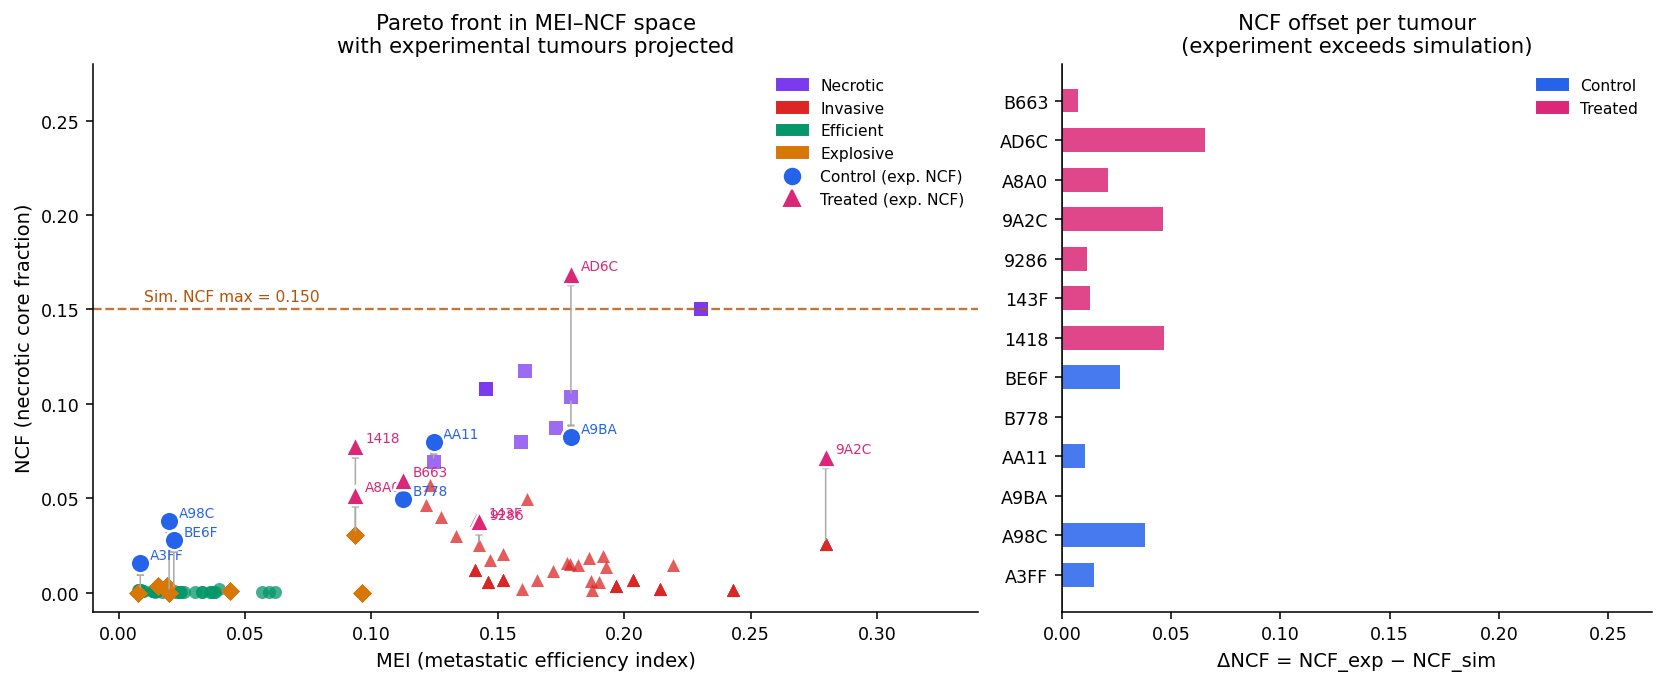

In [29]:
# %% [Cell 19]  Figure 1 — Pareto-front strategy map
# ============================================================
fig1 = fig_pareto_strategy_map(pf, matches)
save_figure(fig1, "pareto_front_strategy_map.png")

  ✓  saved  →  D:/MMRES - Courses/2025-2026/Research Project/TFM/Code development/results/final-data/pareto_matching-2/parameter_space_alpha_beta.png


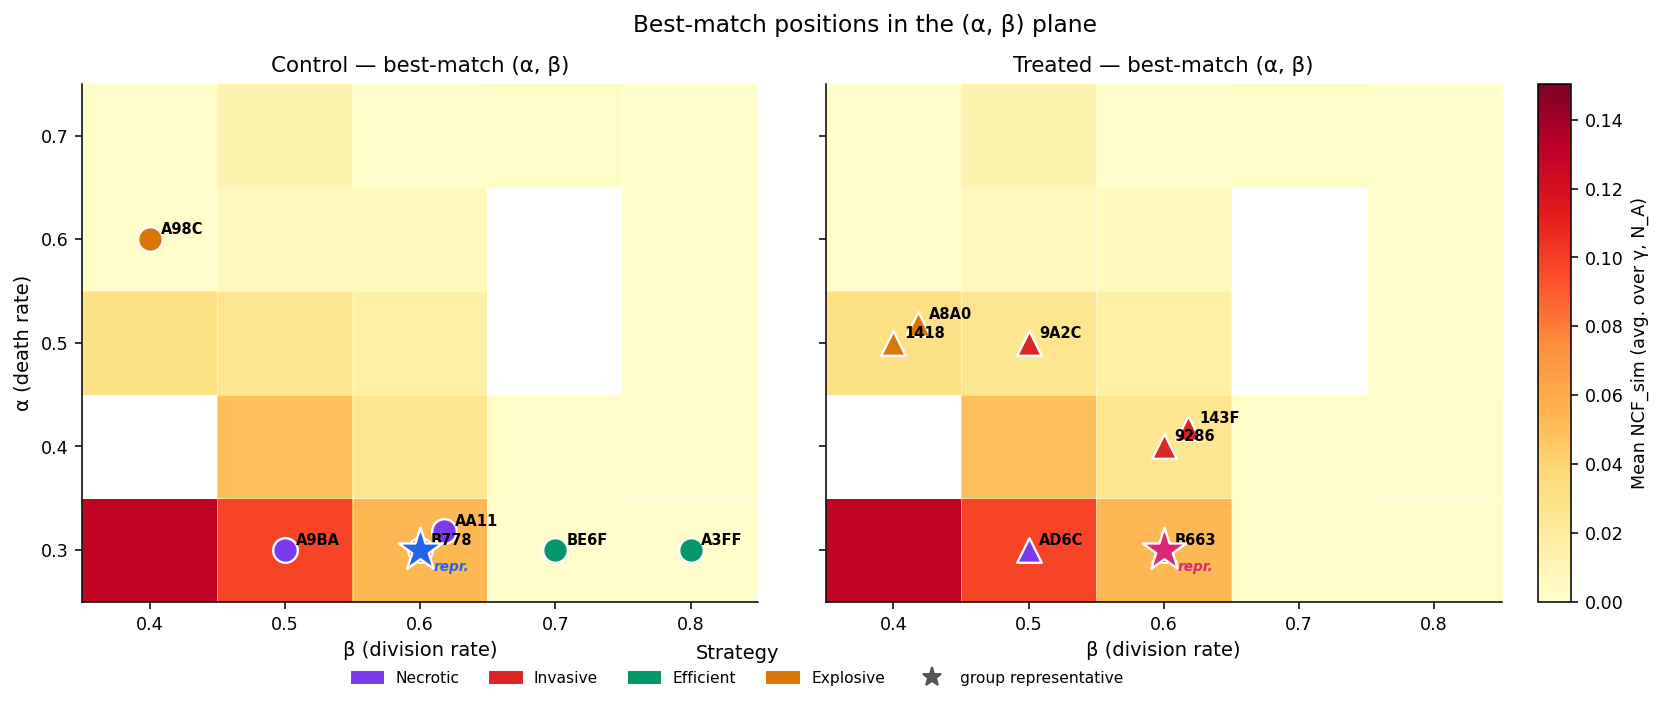

In [30]:
# %% [Cell 20]  Figure 2 — (α, β) parameter space  [with representative ★]
# ============================================================
fig2 = fig_parameter_space_alpha_beta(pf, matches, representatives)
save_figure(fig2, "parameter_space_alpha_beta.png")

  ✓  saved  →  D:/MMRES - Courses/2025-2026/Research Project/TFM/Code development/results/final-data/pareto_matching-2/group_parameter_comparison.png


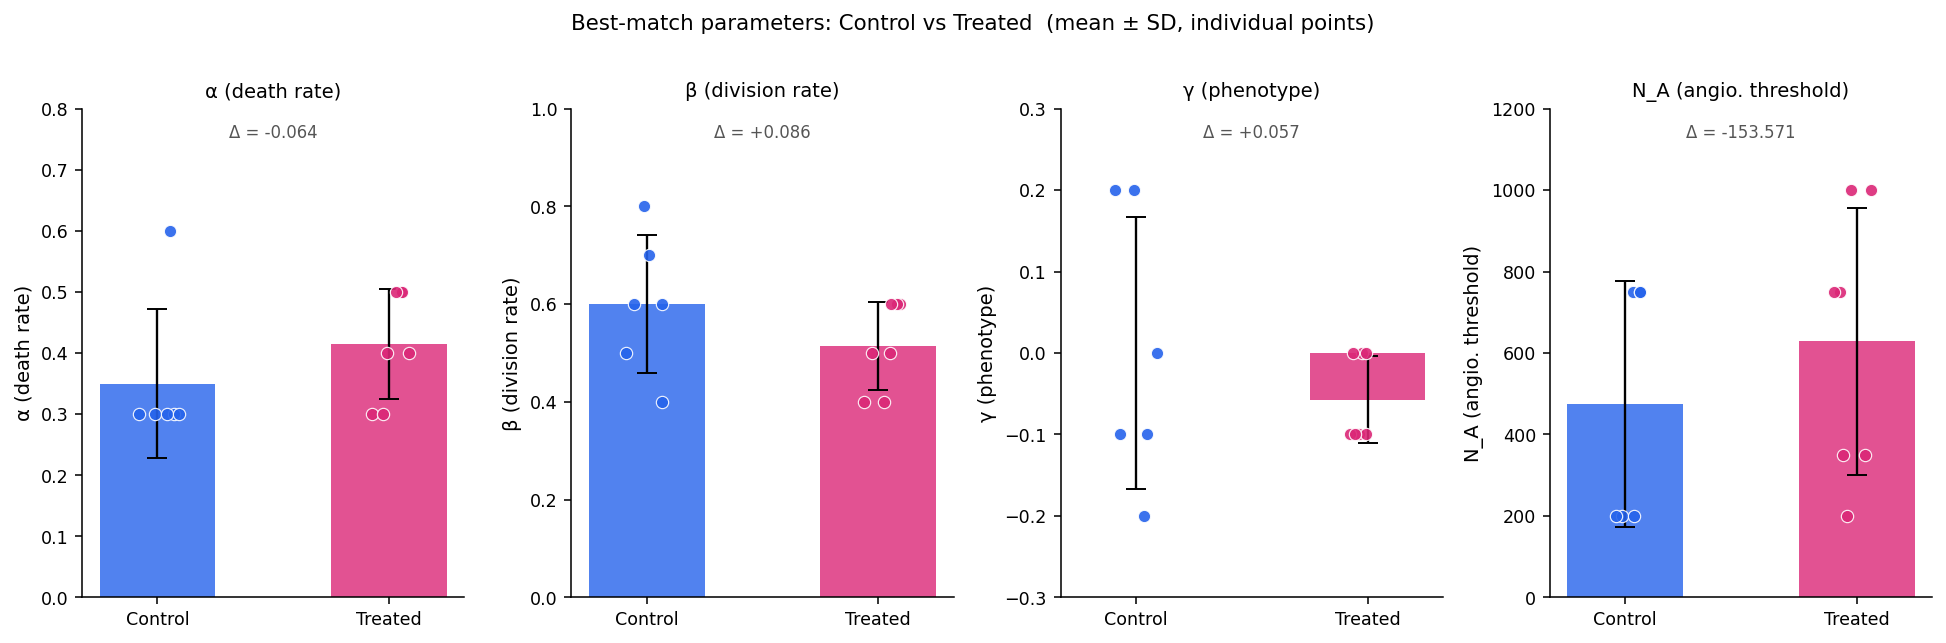

In [31]:
# %% [Cell 21]  Figure 3 — group parameter comparison
# ============================================================
fig3 = fig_group_parameter_comparison(matches)
save_figure(fig3, "group_parameter_comparison.png")

  ✓  saved  →  D:/MMRES - Courses/2025-2026/Research Project/TFM/Code development/results/final-data/pareto_matching-2/group_objective_comparison.png


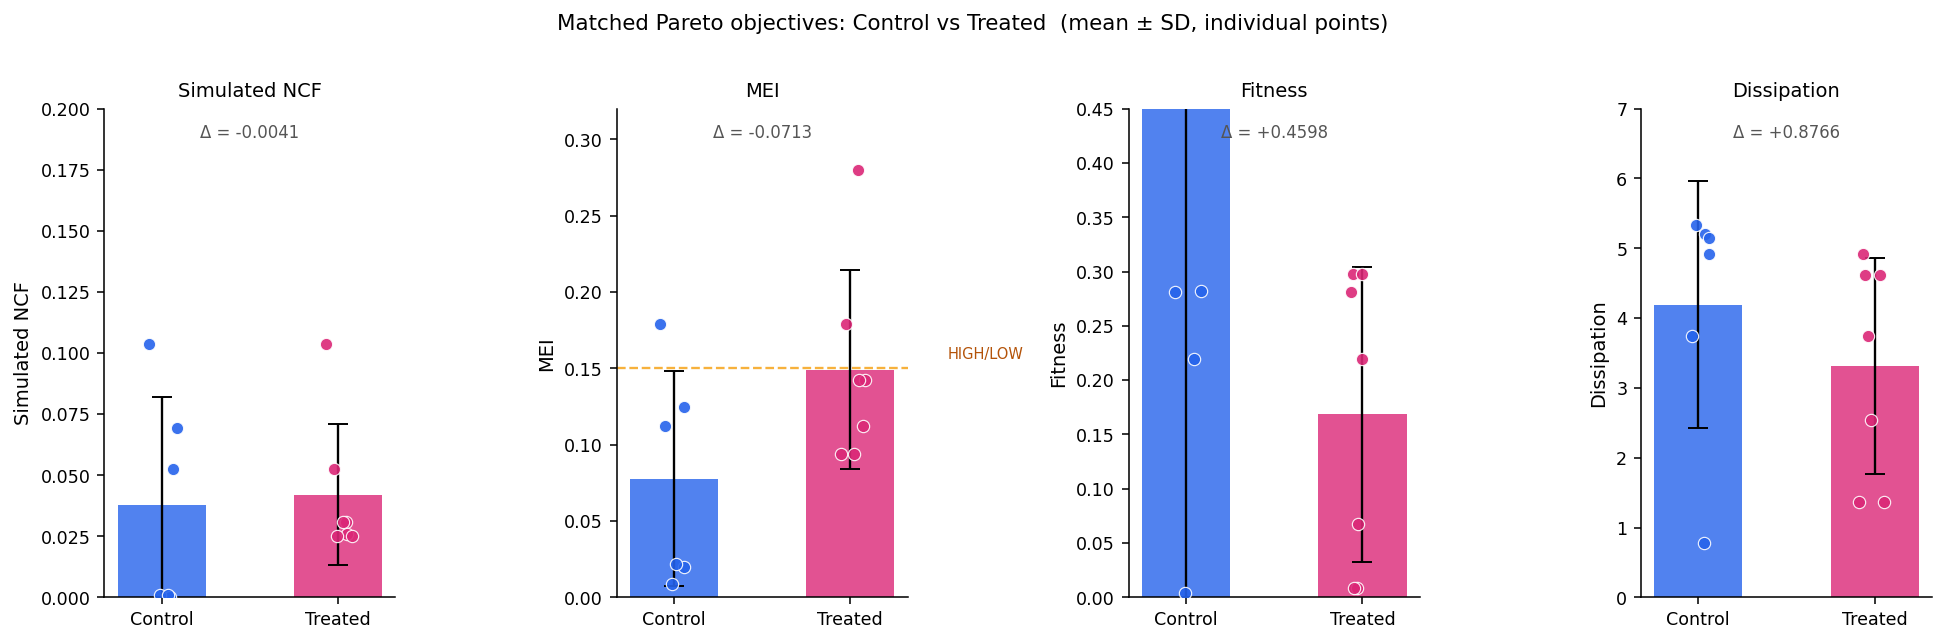

In [32]:
# %% [Cell 22]  Figure 4 — group objective comparison
# ============================================================
fig4 = fig_group_objective_comparison(matches)
save_figure(fig4, "group_objective_comparison.png")

  ✓  saved  →  D:/MMRES - Courses/2025-2026/Research Project/TFM/Code development/results/final-data/pareto_matching-2/parallel_coordinates.png


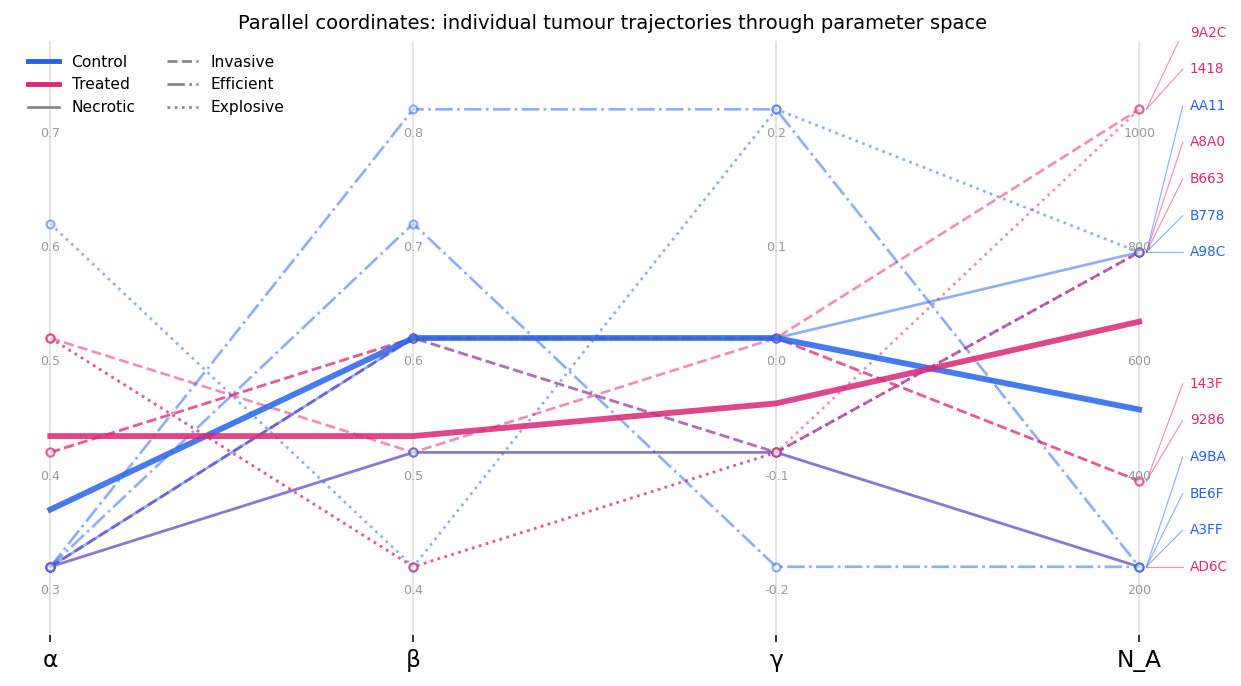

In [ ]:
# %% [Cell 23]  Figure 5 — parallel coordinates
# ============================================================
fig5 = fig_parallel_coordinates(matches)
save_figure(fig5, "parallel_coordinates.png")

  ✓  saved  →  D:/MMRES - Courses/2025-2026/Research Project/TFM/Code development/results/final-data/pareto_matching-2/per_tumour_distance_ranking.png


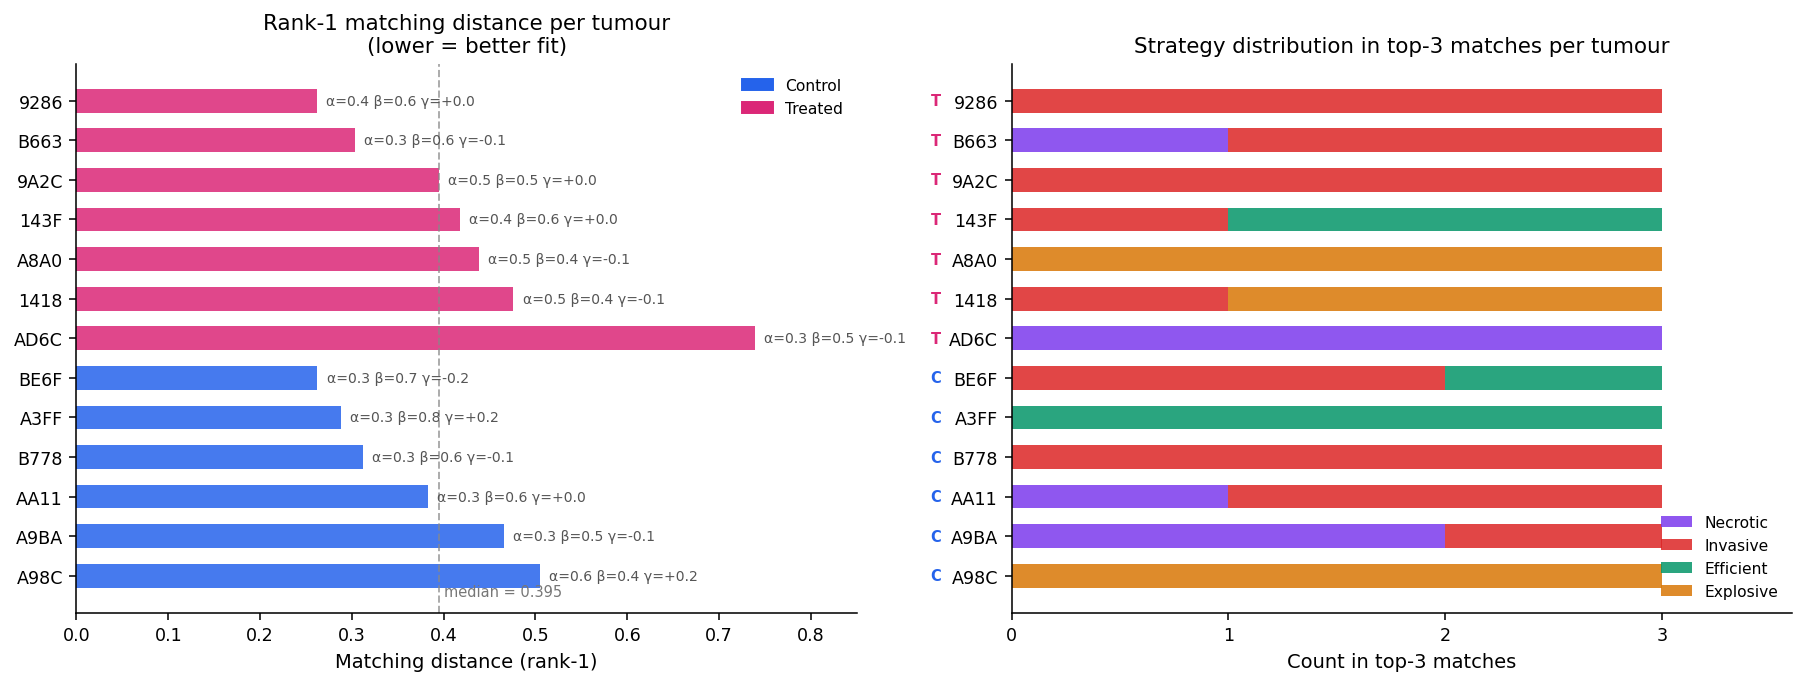

In [34]:
# %% [Cell 24]  Figure 6 — per-tumour distance ranking
# ============================================================
fig6 = fig_per_tumour_distance_ranking(matches)
save_figure(fig6, "per_tumour_distance_ranking.png")

In [35]:
# %% [Cell 25]  Group representatives — centroid-match report
# ============================================================
print_representatives_report(representatives)


════════════════════════════════════════════════════════════════════════════════
  GROUP REPRESENTATIVE PARETO POINT  (centroid-match)
  Single (α, β, γ, N_A) combo that minimises mean distance to
  all tumours in each group simultaneously.
════════════════════════════════════════════════════════════════════════════════

  Control  (n=6 tumours,  centroid dist = 0.23984)
  ────────────────────────────────────────────────────────────────────────────────
    α = 0.3    β = 0.6    γ = +0.1    N_A = 500
    Strategy   : Invasive
    NCF_sim    : 0.04634
    MEI        : 0.12146
    Fitness    : 0.32930
    Dissipation: 5.1725
    β(1+γ)     : 0.6600   (effective rim division rate)
    C_est      : 0.3695   (estimated mean hypoxia ratio)

  Treated  (n=7 tumours,  centroid dist = 0.31334)
  ────────────────────────────────────────────────────────────────────────────────
    α = 0.3    β = 0.6    γ = -0.1    N_A = 750
    Strategy   : Invasive
    NCF_sim    : 0.05243
    MEI        : 0.112